В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [5]:
from process_bank_churn import preprocess_data
import pandas as pd
import numpy as np

In [2]:
raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df)

X_train = data.X_train
train_targets = data.y_train
X_val = data.X_val
val_targets = data.y_val
features = data.feature_names

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

def roc_auc_score_on_data(model):
  train_preds_proba = model.predict_proba(X_train)[:, 1]
  roc_auc = roc_auc_score(train_targets, train_preds_proba)
  print(f"Train ROC AUC: {roc_auc:.2f}")
  val_preds_proba = model.predict_proba(X_val)[:, 1]
  roc_auc = roc_auc_score(val_targets, val_preds_proba)
  print(f"Validation ROC AUC: {roc_auc:.2f}")

roc_auc_score_on_data(knn)

Train ROC AUC: 0.96
Validation ROC AUC: 0.85


Існує суттєва різниця в ефективності моделі на тренувальних та тестувальних даних, при цьому на тестувальних даних оцінка більше 0.9 - можна судити про перенавчання моделі (high variance), тому модель ну дуже хороша і можна покращити.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [11]:
from sklearn.model_selection import GridSearchCV

params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc')
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

In [12]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(19)} 0.8833086769495468


In [14]:
roc_auc_score_on_data(knn_best)

Train ROC AUC: 0.92
Validation ROC AUC: 0.89


Показники вирівнялись для можелі з оптимальним параметром knn. Модель краще за пепередню з випадковим параметром, але трохи гірша на валідаційних даних (для дева було Train ROC AUC: 0.92 та Validation ROC AUC: 0.91)

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [15]:
%%time
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
params_dt = {'max_depth': np.arange(1, 21, 2), 'max_leaf_nodes': np.arange(2, 11, 1)}
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)

CPU times: user 4.11 s, sys: 0 ns, total: 4.11 s
Wall time: 4.12 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [17]:
dt_best = dt_gs.best_estimator_

print(dt_gs.best_params_, dt_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.9037698264744622


In [18]:
roc_auc_score_on_data(dt_best)

Train ROC AUC: 0.91
Validation ROC AUC: 0.89


Модель вийшла гарна, але не краща за ту, що знайшла вручну, або за алгоритмом KNN

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [19]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [20]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
%%time
dt_rs = RandomizedSearchCV(dt, params_dt, cv=3, scoring='roc_auc', random_state=42, n_iter=40)
dt_rs.fit(X_train, train_targets)

CPU times: user 1.29 s, sys: 1.93 ms, total: 1.29 s
Wall time: 1.31 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [25]:
dt_random_search_best = dt_rs.best_estimator_

print(dt_rs.best_params_, dt_rs.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.916076893290036


In [26]:
roc_auc_score_on_data(dt_random_search_best)

Train ROC AUC: 0.92
Validation ROC AUC: 0.90


Ця модель дерева з RandomizedSearchCV (1) вийшла трохи краще за дерево+GridSearchCV (2). В (1) max_leaf_nodes було 10, а при (2) - 14. Також max_depth в (2) визначилась значно більше - 16 проти 5. Хоча сама ефективніть моделі за ROC AUC не значно зросла, але дереву сильно розрослось і ускладнилось.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

Вирішила зберігти всі 3 передбачення (з пошуком гіперпараметрів) оскільки всі вони показали гарні результати і цікаво які вийдуть на тестових даних

In [28]:
from process_bank_churn import preprocess_new_data
test_df = pd.read_csv('test.csv').drop('id',axis=1)
test_data = preprocess_new_data(test_df, data.categorical_encoder, data.scaler)

In [29]:
def make_predictions(model, name):
  test_predictions = model.predict_proba(test_data)[:,1]
  submission_raw_df = pd.read_csv('sample_submission.csv')
  submission_raw_df['Exited'] = test_predictions
  submission_raw_df.to_csv("submission_"+name+".csv", index=False)

In [30]:
make_predictions(knn_best, "knn_gridS")
make_predictions(dt_best, "tree_gridS")
make_predictions(dt_random_search_best, "tree_randomS")

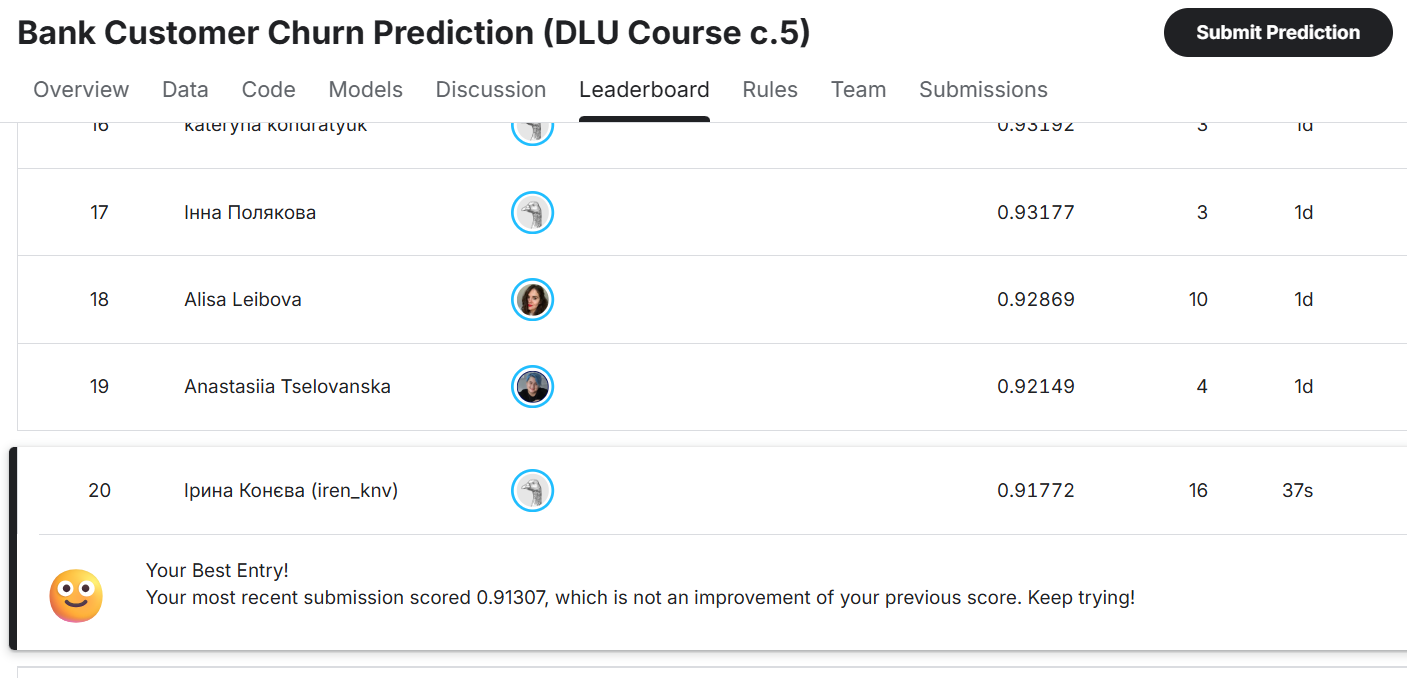